<a href="https://colab.research.google.com/github/Saranya546/creditcard/blob/main/DAY_3_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# credit card fraud detection


In [16]:
# downloading the dataset
!pip install kaggle


In [17]:
!mkdir -p ~/.kaggle

In [18]:
import json
import os

kaggle_info = {
    "username": "bulusulakshmisaranya",
    "key": "KGAT_8360fc1d43ff22cdf1373463b1edfc57"
}

# Create the .kaggle directory if it doesn't exist
os.makedirs('/root/.kaggle/', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(kaggle_info, file)

In [19]:
!chmod 600 /root/.kaggle/kaggle.json

In [20]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)


In [21]:
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: creditcard.csv          


In [22]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print(df.head())
print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

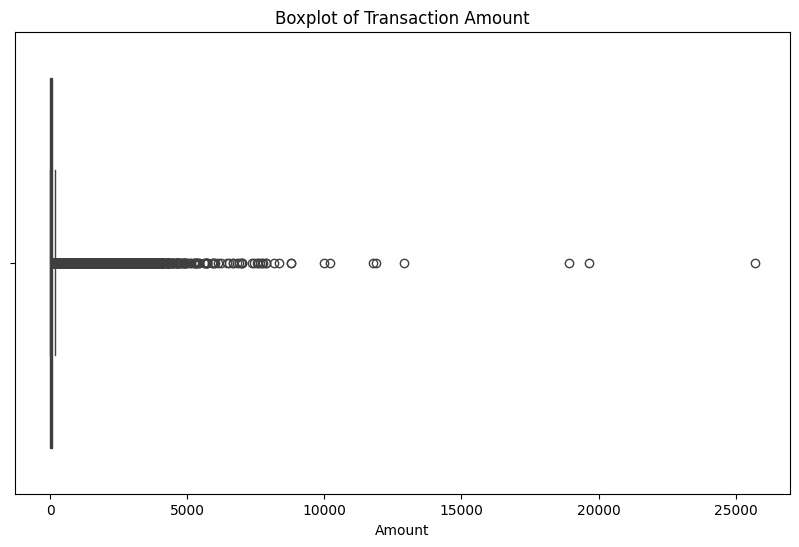

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Amount'])
plt.title('Boxplot of Transaction Amount')
plt.xlabel('Amount')
plt.show()

In [24]:
null_counts = df.isnull().sum()
print("Sum of null values for each feature:")
print(null_counts[null_counts > 0])

Sum of null values for each feature:
Series([], dtype: int64)


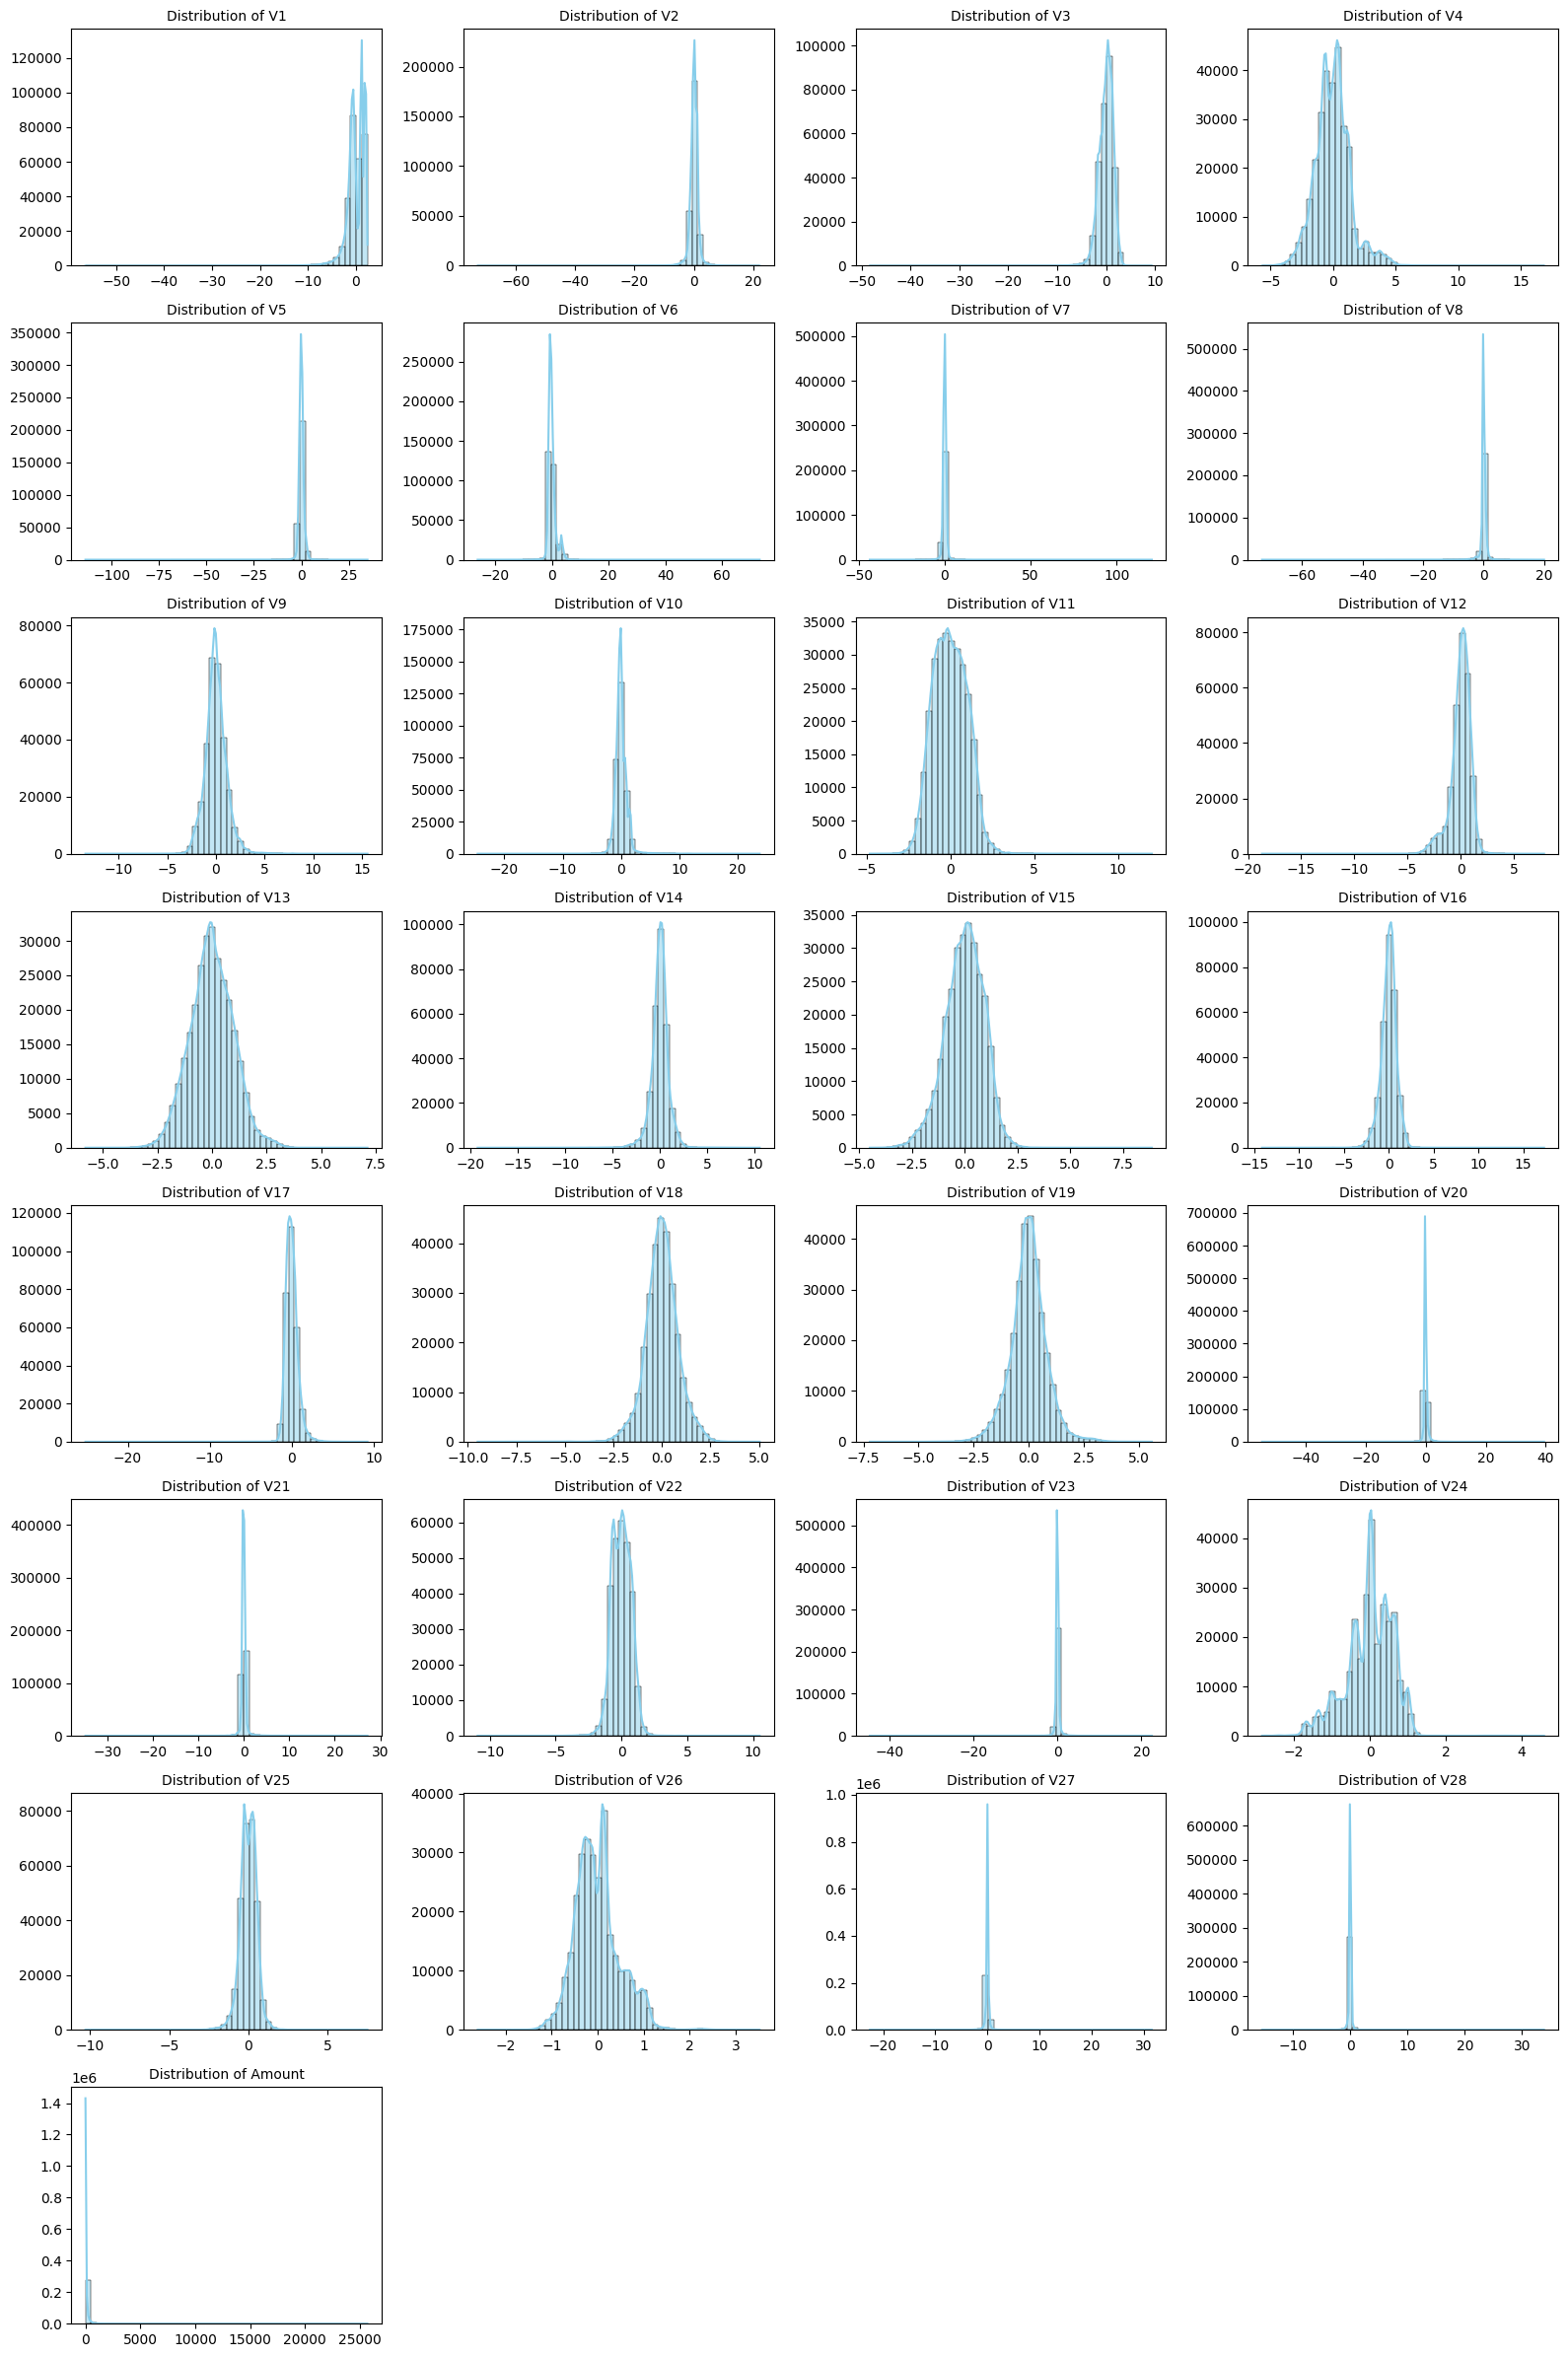

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all columns except 'Time' and 'Class'
features = df.drop(columns=['Time', 'Class']).columns

# Determine the number of rows and columns for the subplots grid
n_cols = 4  # Number of columns in the subplot grid
n_rows = (len(features) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[feature], kde=True, bins=50, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=10)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [26]:
# perform equal-depth binning on amount

# Define the number of bins
num_bins_depth = 10

# Perform equal-depth binning on the 'Amount' feature
# use try-except block to handle potential errors if not enough unique values for num_bins_depth
try:
    df['Amount_qcut'] = pd.qcut(df['Amount'], q=num_bins_depth, labels=False, duplicates='drop')
    # Display the value counts for the binned 'Amount'
    print("Value counts for 'Amount_qcut' (Equal-Depth Binning):")
    print(df['Amount_qcut'].value_counts().sort_index())
except ValueError as e:
    print(f"Could not perform equal-depth binning with {num_bins_depth} bins: {e}")
    print("This might happen if there are too few unique 'Amount' values for the requested number of bins. Trying with fewer bins or adjusting 'q'.")
    # Optionally, try with a smaller number of bins or different strategy
    # For instance, using 4 bins if 10 failed
    try:
        df['Amount_qcut'] = pd.qcut(df['Amount'], q=4, labels=False, duplicates='drop')
        print("\nRetrying with 4 bins for 'Amount_qcut':")
        print(df['Amount_qcut'].value_counts().sort_index())
    except ValueError as e_retry:
        print(f"Retry with 4 bins also failed: {e_retry}")

Value counts for 'Amount_qcut' (Equal-Depth Binning):
Amount_qcut
0    30492
1    26473
2    28559
3    28405
4    28714
5    28375
6    28366
7    28915
8    28050
9    28458
Name: count, dtype: int64


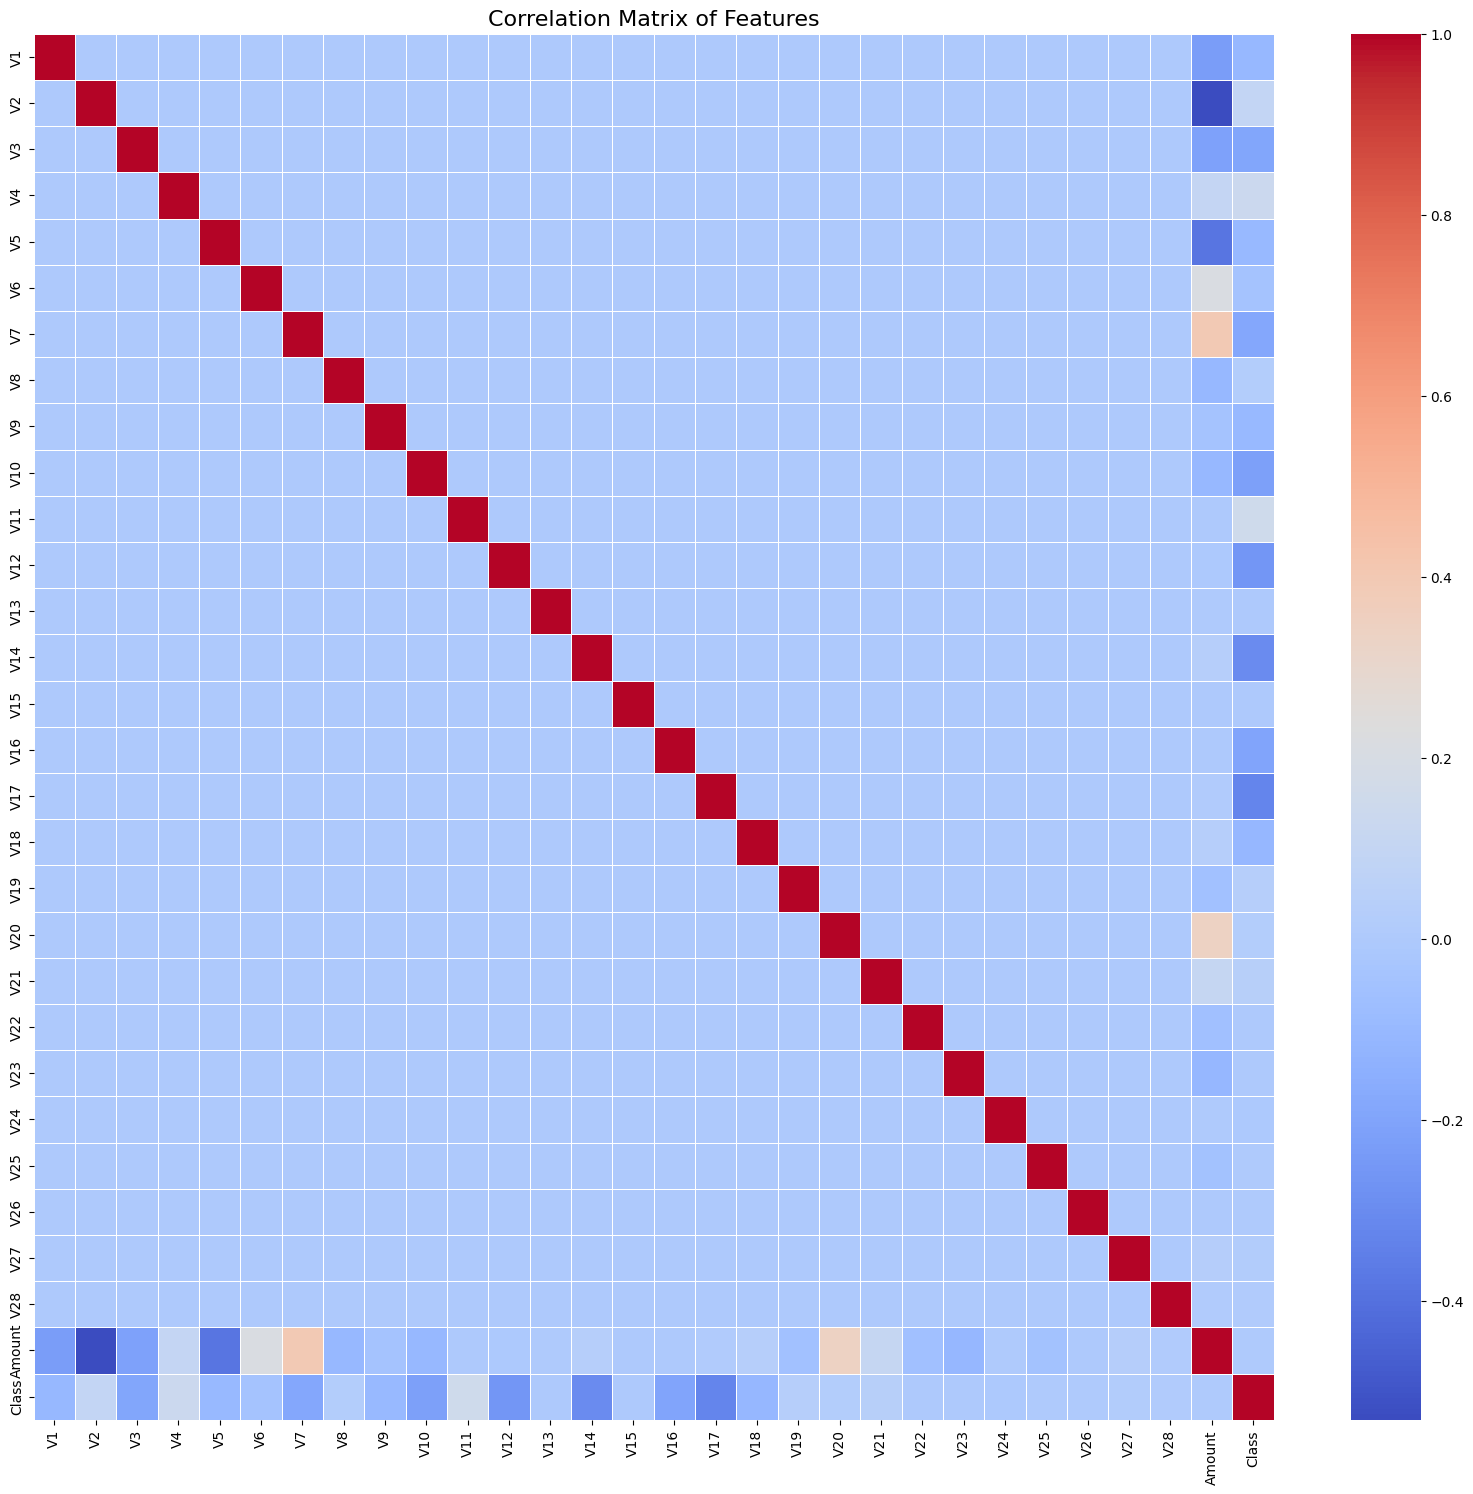

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix (excluding 'Time' and 'Amount_qcut' for clearer visualization with original 'Amount')
# 'Amount_qcut' is a binned version of 'Amount', so including both might be redundant for correlation map purposes.
correlation_matrix = df.drop(columns=['Time', 'Amount_qcut'], errors='ignore').corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features', fontsize=16)
plt.show()

Explained variance ratio for each principal component:
[0.12965978 0.09215688 0.07769907 0.06775123 0.06438501 0.05998691
 0.05172213 0.04820995 0.04079208 0.04006888 0.03521102 0.03374251
 0.03347779 0.03105576 0.02831479 0.02594957 0.02437987 0.02374335
 0.02239563 0.0200861  0.01823406 0.01779866 0.01317895]


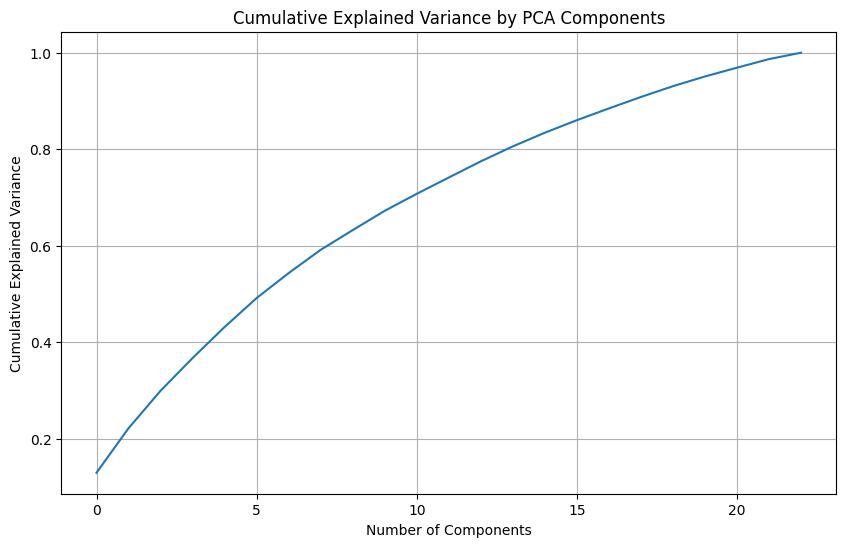

Shape of original 'V' features: (284807, 23)
Shape of PCA transformed 'V' features: (284807, 23)


In [28]:
# Do the PCA of fetures V1,V2...V23
from sklearn.decomposition import PCA
import numpy as np

# Select the 'V' features for PCA
v_features = [f'V{i}' for i in range(1, 24)] # V1 to V23
X = df[v_features]

# Initialize PCA
pca = PCA(n_components=None) # n_components=None means all components are kept

# Fit PCA on the data
pca.fit(X)

# Transform the data
X_pca = pca.transform(X)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

print("Explained variance ratio for each principal component:")
print(explained_variance_ratio)

# Optionally, visualize the explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(explained_variance_ratio))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()

print(f"Shape of original 'V' features: {X.shape}")
print(f"Shape of PCA transformed 'V' features: {X_pca.shape}")

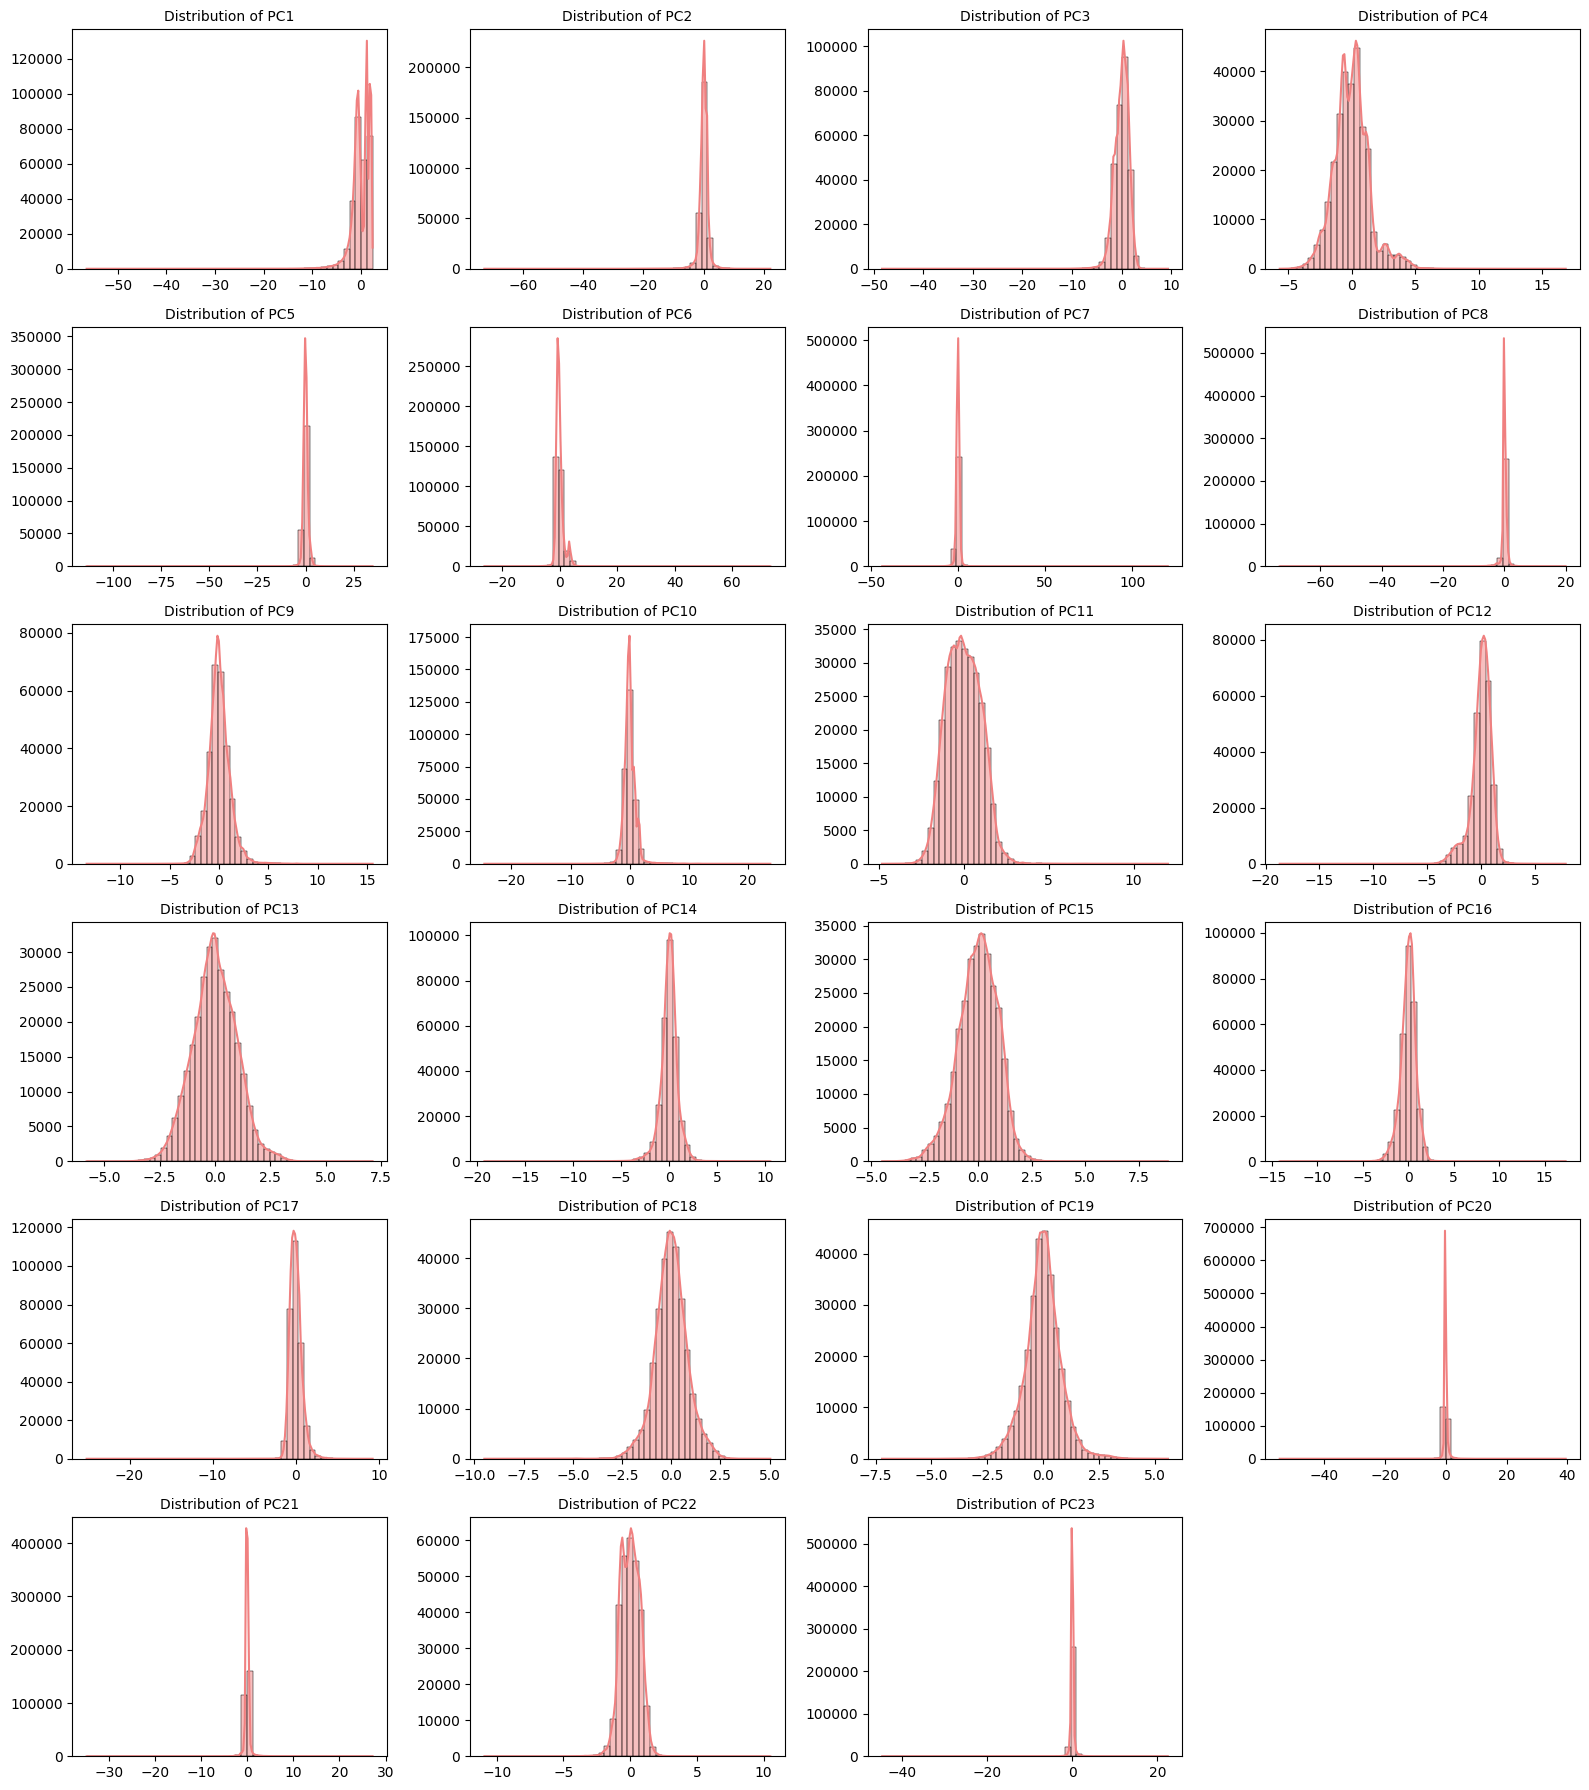

In [30]:
# plot the histrogram distrubuution for new PCA components
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert X_pca to a DataFrame for easier plotting with seaborn
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

# Determine the number of rows and columns for the subplots grid
n_components = pca_df.shape[1]
n_cols = 4  # Number of columns in the subplot grid
n_rows = (n_components + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, column in enumerate(pca_df.columns):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(pca_df[column], kde=True, bins=50, color='lightcoral')
    plt.title(f'Distribution of {column}', fontsize=10)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [31]:
# do normalisation on all PCA components
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
X_scaled = scaler.fit_transform(X_pca)

In [29]:
# do robust scaler on amount
from sklearn.preprocessing import RobustScaler

# Initialize the RobustScaler
scaler = RobustScaler()

# Reshape the 'Amount' column to a 2D array as required by the scaler
df['Amount_RobustScaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

print("First 5 rows of 'Amount' and 'Amount_RobustScaled':")
print(df[['Amount', 'Amount_RobustScaled']].head())

First 5 rows of 'Amount' and 'Amount_RobustScaled':
   Amount  Amount_RobustScaled
0  149.62             1.783274
1    2.69            -0.269825
2  378.66             4.983721
3  123.50             1.418291
4   69.99             0.670579


In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
!git clone https://github.com/Saranya546/creditcard.git

Cloning into 'creditcard'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [34]:
!git config --global user.email "saranyabulusulakshmi@gmail.com"
!git config --global user.name "Saranya546"

In [37]:
!pwd
!ls

/content
creditcard  creditcard.csv  creditcardfraud.zip  drive	sample_data


In [39]:
!ls

creditcard  creditcard.csv  creditcardfraud.zip  drive	sample_data


In [41]:
%cd creditcard


/content/creditcard


In [42]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [43]:


!git add .
!git commit -m "Added fraud detection project"
!git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address
